# Analyse exploratoire — Tunisia Weather Prediction

**Auteur :** Ahmed Ben Arfa

Ce notebook est genere par `_build_eda.py`. Ne pas l'editer directement :
toute correction se fait dans le generateur, puis on regenere.

Il repond a quatre questions :

1. le jeu est-il exploitable en l'etat ?
2. quels contrastes climatiques structurent la Tunisie ?
3. quelle est la structure temporelle du signal ?
4. **quelles variables peut-on utiliser en production ?**

La quatrieme est la plus consequente : elle decide des variables admises
comme features pour la modelisation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RACINE = Path.cwd()
while not (RACINE / "data").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE / "01_etl"))

import config

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

MARINE = "#0b3594"
BRIQUE = "#c44e52"

df = pd.read_parquet(config.PARQUET_PROPRE)
df["annee"] = df["time"].dt.year
df["mois"] = df["time"].dt.month
df["heure"] = df["time"].dt.hour

# Les 31 variables meteorologiques, hors identifiants et geographie
METEO = [c for c in df.columns
         if c not in ("gouvernorat", "time", "latitude", "longitude",
                      "elevation", "annee", "mois", "heure")]

print(f"{len(df):,} lignes x {df.shape[1]} colonnes")
print(f"{len(METEO)} variables meteorologiques")

1,585,728 lignes x 39 colonnes
31 variables meteorologiques


## 1. Volumetrie et couverture

In [2]:
pd.DataFrame({
    "Caracteristique": [
        "Lignes", "Colonnes", "Gouvernorats", "Debut", "Fin",
        "Heures par gouvernorat", "Valeurs manquantes",
        "Doublons (gouvernorat, heure)",
    ],
    "Valeur": [
        f"{len(df):,}", df.shape[1], df["gouvernorat"].nunique(),
        str(df["time"].min()), str(df["time"].max()),
        f"{df.groupby('gouvernorat', observed=True).size().iloc[0]:,}",
        int(df.isna().sum().sum()),
        int(df.duplicated(["gouvernorat", "time"]).sum()),
    ],
})

,Caracteristique,Valeur
0,Lignes,"1,585,728"
1,Colonnes,39
2,Gouvernorats,24
3,Debut,2019-01-01 00:00:00
4,Fin,2026-07-15 23:00:00
5,Heures par gouvernorat,"66,072"
6,Valeurs manquantes,0
7,"Doublons (gouvernorat, heure)",0


In [3]:
# Continuite : chaque serie doit avancer d'exactement une heure
ecarts = (df.sort_values("time")
          .groupby("gouvernorat", observed=True)["time"]
          .diff().dropna().value_counts())
print(ecarts.to_string())
print("\nUne seule valeur d'ecart = aucun trou, aucune heure dupliquee.")
print("La Tunisie n'appliquant pas l'heure d'ete, il n'y a pas non plus")
print("d'artefact de changement d'heure.")

time
0 days 01:00:00    1585704

Une seule valeur d'ecart = aucun trou, aucune heure dupliquee.
La Tunisie n'appliquant pas l'heure d'ete, il n'y a pas non plus
d'artefact de changement d'heure.


## 2. Qualite des donnees

Trois points releves au profilage. Les deux premiers ont une consequence
directe sur la modelisation.

In [4]:
# 2.1 Humidite du sol : la correction du nettoyage a-t-elle bien ete appliquee ?
couches = [c for c in df.columns if c.startswith("soil_moisture")]
df[couches].min().to_frame("minimum apres nettoyage")

,minimum apres nettoyage
soil_moisture_0_to_7cm,0.0
soil_moisture_7_to_28cm,0.0
soil_moisture_28_to_100cm,0.0


Une teneur en eau volumique ne peut pas etre negative. Le jeu brut descendait
a −0,013 m³/m³ sur environ 0,03 % des lignes, concentrees sur les gouvernorats
arides du sud — un artefact numerique de la reanalyse sur sols tres secs, ou
la grandeur oscille autour de zero. `01_etl/clean.py` les ramene a zero.

In [5]:
# 2.2 rain est-elle redondante avec precipitation ?
ecart = (df["precipitation"] - df["rain"]).abs()
print(f"Lignes ou les deux different : {(ecart > 1e-9).sum():,}")
print(f"Correlation                  : {df['precipitation'].corr(df['rain']):.6f}")
print(f"Lignes avec neige            : {(df['snowfall'] > 0).sum():,}")

Lignes ou les deux different : 144
Correlation                  : 0.999760
Lignes avec neige            : 144


Les deux colonnes ne different que sur les lignes ou il neige. Les conserver
toutes deux introduirait une colinearite quasi parfaite sans apport
d'information : `precipitation` suffit.

In [6]:
# 2.3 Points de grille : certains gouvernorats partagent une latitude
geo = (df.groupby("gouvernorat", observed=True)[["latitude", "longitude", "elevation"]]
       .first())
geo[geo["latitude"].duplicated(keep=False)].sort_values("latitude")

,latitude,longitude,elevation
gouvernorat,,,
Nabeul,36.449910,10.691906,11.0
Zaghouan,36.449910,10.104439,172.0
Ben Arous,36.731106,10.275591,8.0
Beja,36.731106,9.212599,247.0
Manouba,36.801403,10.052563,28.0
Tunis,36.801403,10.170828,11.0


La resolution ERA5 ne separe pas finement des chefs-lieux voisins. Les quatre
gouvernorats du Grand Tunis occupent des points quasi confondus : un
regroupement de ces quatre-la, au clustering de la phase 04, traduirait la
proximite geographique autant que la similarite climatique. A ne pas presenter
comme une decouverte.

## 3. Contrastes regionaux

In [7]:
profil = (df.groupby("gouvernorat", observed=True)
          .agg(temp_min=("temperature_2m", "min"),
               temp_moy=("temperature_2m", "mean"),
               temp_max=("temperature_2m", "max"),
               altitude=("elevation", "first"),
               latitude=("latitude", "first"))
          .round(1)
          .sort_values("temp_moy"))
profil

,temp_min,temp_moy,temp_max,altitude,latitude
gouvernorat,,,,,
Kef,-3.4,17.0,44.0,637.0,36.2
Kasserine,-3.6,17.7,44.4,674.0,35.2
Beja,-1.6,18.3,46.8,247.0,36.7
Siliana,-1.6,18.5,45.2,431.0,36.1
Zaghouan,0.4,19.0,47.1,172.0,36.4
Nabeul,3.1,19.2,42.7,11.0,36.4
Ariana,1.2,19.3,48.3,9.0,36.9
Bizerte,4.9,19.4,46.9,5.0,37.3
Tunis,0.7,19.4,48.5,11.0,36.8


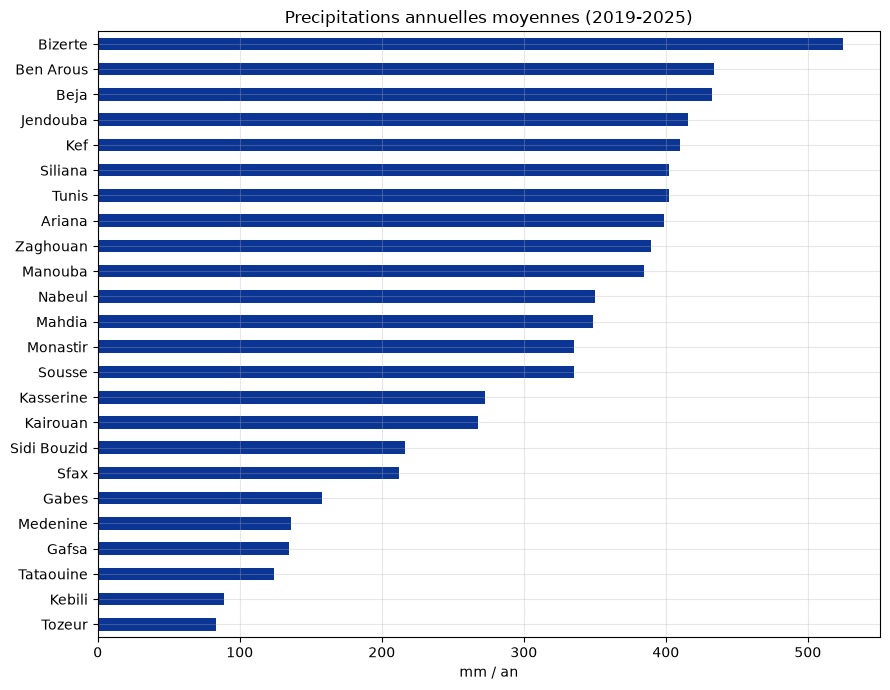

Rapport nord / sud : 6.3


In [8]:
# Precipitations annuelles moyennes, sur les annees completes uniquement
completes = df[df["annee"].between(2019, 2025)]
cumul = (completes.groupby(["gouvernorat", "annee"], observed=True)["precipitation"]
         .sum()
         .groupby("gouvernorat", observed=True).mean()
         .sort_values())

ax = cumul.plot(kind="barh", color=MARINE, figsize=(9, 7))
ax.set_xlabel("mm / an")
ax.set_ylabel("")
ax.set_title("Precipitations annuelles moyennes (2019-2025)")
plt.tight_layout()
plt.show()

print(f"Rapport nord / sud : {cumul.max() / cumul.min():.1f}")

Le gradient nord-sud est le fait structurant du jeu. C'est ce contraste que le
clustering de la phase 04 doit faire ressortir.

In [9]:
# L'altitude explique-t-elle la temperature aussi bien que la latitude ?
correlations = profil[["temp_moy", "altitude", "latitude"]].corr().round(3)
correlations

,temp_moy,altitude,latitude
temp_moy,1.000,-0.585,-0.697
altitude,-0.585,1.000,-0.063
latitude,-0.697,-0.063,1.000


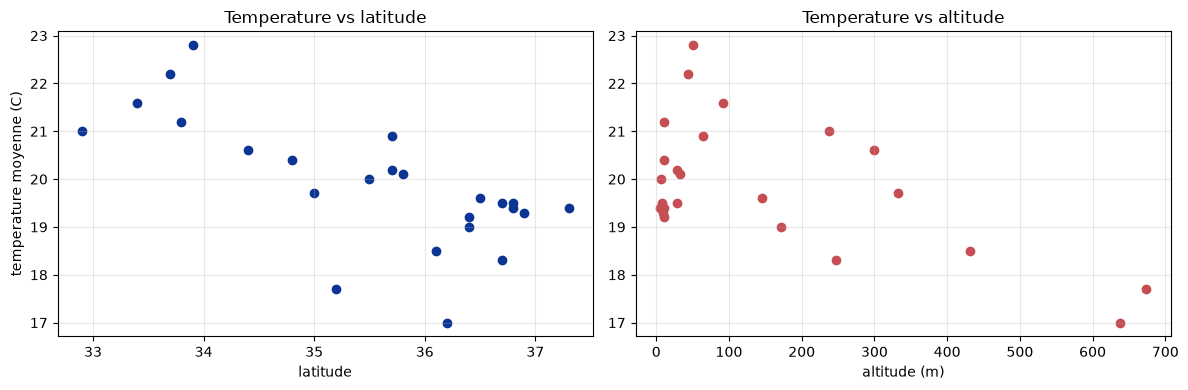

In [10]:
fig, (g, d) = plt.subplots(1, 2, figsize=(12, 4))

g.scatter(profil["latitude"], profil["temp_moy"], color=MARINE)
g.set_xlabel("latitude")
g.set_ylabel("temperature moyenne (C)")
g.set_title("Temperature vs latitude")

d.scatter(profil["altitude"], profil["temp_moy"], color=BRIQUE)
d.set_xlabel("altitude (m)")
d.set_ylabel("")
d.set_title("Temperature vs altitude")

plt.tight_layout()
plt.show()

Les deux facteurs jouent. Le classement thermique n'est pas purement
latitudinal : les gouvernorats les plus frais sont aussi les plus eleves. Cela
justifie de conserver **latitude, longitude et altitude** comme variables
statiques du modele global — ce sont elles qui porteront les specificites
locales.

## 4. Structure temporelle

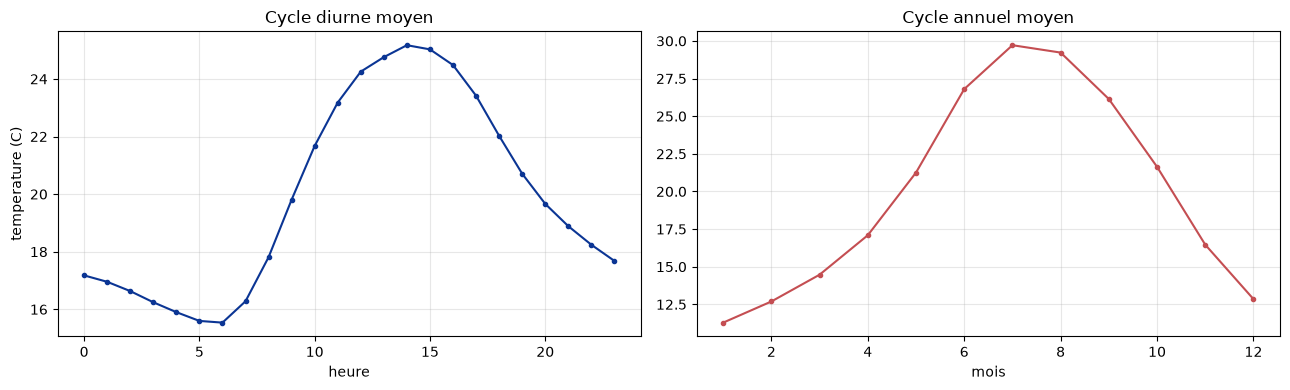

In [11]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4))

(df.groupby("heure", observed=True)["temperature_2m"].mean()
   .plot(ax=g, color=MARINE, marker="o", ms=3))
g.set_title("Cycle diurne moyen")
g.set_xlabel("heure")
g.set_ylabel("temperature (C)")

(df.groupby("mois", observed=True)["temperature_2m"].mean()
   .plot(ax=d, color=BRIQUE, marker="o", ms=3))
d.set_title("Cycle annuel moyen")
d.set_xlabel("mois")
d.set_ylabel("")

plt.tight_layout()
plt.show()

**Deux saisonnalites coexistent** : un cycle diurne de 24 h et un cycle annuel
de 8 766 h. C'est ce qui rendra SARIMA insuffisant a lui seul en phase 05 — il
ne gere qu'une seule periode saisonniere, et une periode de 8 766 est
numeriquement infaisable. D'ou le recours aux termes de Fourier.

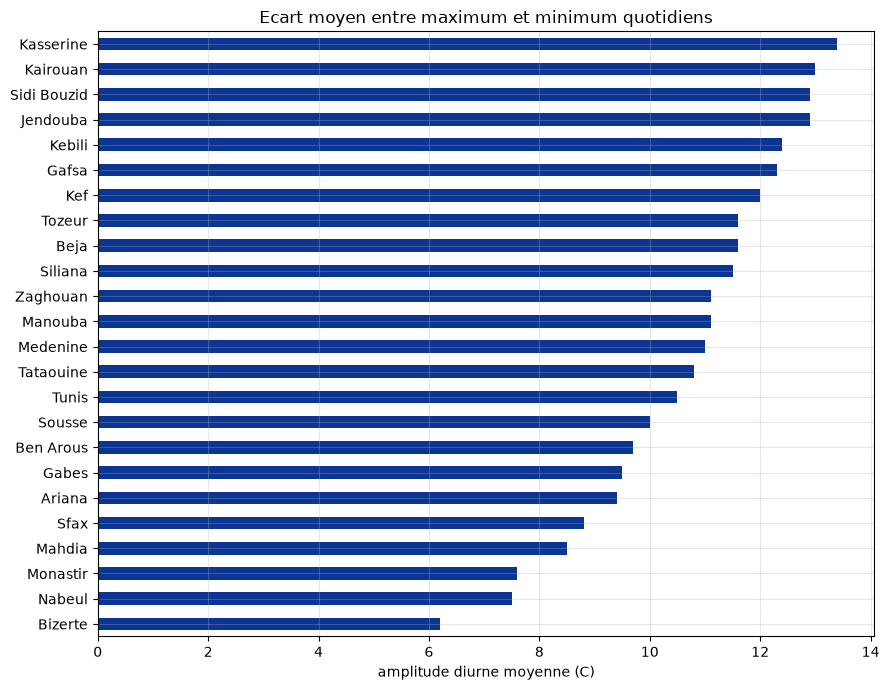

In [12]:
# Amplitude diurne : le sud continental se distingue-t-il du littoral ?
par_jour = (df.assign(jour=df["time"].dt.date)
            .groupby(["gouvernorat", "jour"], observed=True)["temperature_2m"]
            .agg(["min", "max"]))
par_jour["amplitude"] = par_jour["max"] - par_jour["min"]

amplitude = (par_jour.groupby("gouvernorat", observed=True)["amplitude"]
             .mean().round(1).sort_values())

ax = amplitude.plot(kind="barh", color=MARINE, figsize=(9, 7))
ax.set_xlabel("amplitude diurne moyenne (C)")
ax.set_ylabel("")
ax.set_title("Ecart moyen entre maximum et minimum quotidiens")
plt.tight_layout()
plt.show()

## 5. Distributions et formes

Statistiques descriptives, asymetrie et aplatissement des 31 variables
meteorologiques, puis dispersion par famille d'unites.

In [13]:
df[METEO].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature_2m,1585728.0,19.88,8.13,-3.6,13.60,19.20,25.50,50.20
relative_humidity_2m,1585728.0,60.89,22.89,4.0,43.00,63.00,80.00,100.00
dew_point_2m,1585728.0,10.59,6.09,-17.9,6.40,10.50,15.00,27.10
apparent_temperature,1585728.0,18.77,9.36,-7.8,11.20,18.00,26.20,47.60
precipitation,1585728.0,0.04,0.28,0.0,0.00,0.00,0.00,21.00
rain,1585728.0,0.04,0.28,0.0,0.00,0.00,0.00,21.00
snowfall,1585728.0,0.00,0.00,0.0,0.00,0.00,0.00,1.96
pressure_msl,1585728.0,1016.86,5.77,983.3,1013.20,1016.30,1020.40,1038.80
surface_pressure,1585728.0,999.55,22.60,914.7,988.70,1008.40,1014.80,1036.90
cloud_cover,1585728.0,33.88,39.15,0.0,0.00,13.00,72.00,100.00


### Asymetrie et aplatissement

$$
\text{skew} = \frac{1}{N}\frac{\sum_i (x_i - \bar{x})^3}{\sigma^3}
\qquad
\text{kurt} = \frac{1}{N}\frac{\sum_i (x_i - \bar{x})^4}{\sigma^4} - 3
\qquad
$$

Une asymetrie nulle signale une distribution symetrique ; positive, une queue
etiree vers la droite. L'aplatissement est donne en exces (0 pour une loi
normale) : une valeur elevee signale des evenements extremes plus frequents
qu'une gaussienne ne le prevoit.

In [14]:
formes = pd.DataFrame({
    "asymetrie": df[METEO].skew(),
    "aplatissement": df[METEO].kurtosis(),
}).round(2).sort_values("asymetrie", ascending=False)
formes

,asymetrie,aplatissement
snowfall,234.73,69693.87
rain,18.39,528.71
precipitation,18.37,527.02
cloud_cover_low,3.10,9.04
cloud_cover_mid,2.29,4.23
vapour_pressure_deficit,2.12,5.59
direct_radiation,1.36,0.56
et0_fao_evapotranspiration,1.30,0.79
cloud_cover_high,1.26,-0.12
shortwave_radiation,1.10,-0.16


Les variables de precipitation dominent le classement, ce qui est attendu : il
ne pleut pas la plupart des heures, et quand il pleut l'intensite peut etre
forte. Une telle asymetrie ecarte toute hypothese de normalite et rend une
transformation logarithmique pertinente si ces variables devaient etre
modelisees directement.

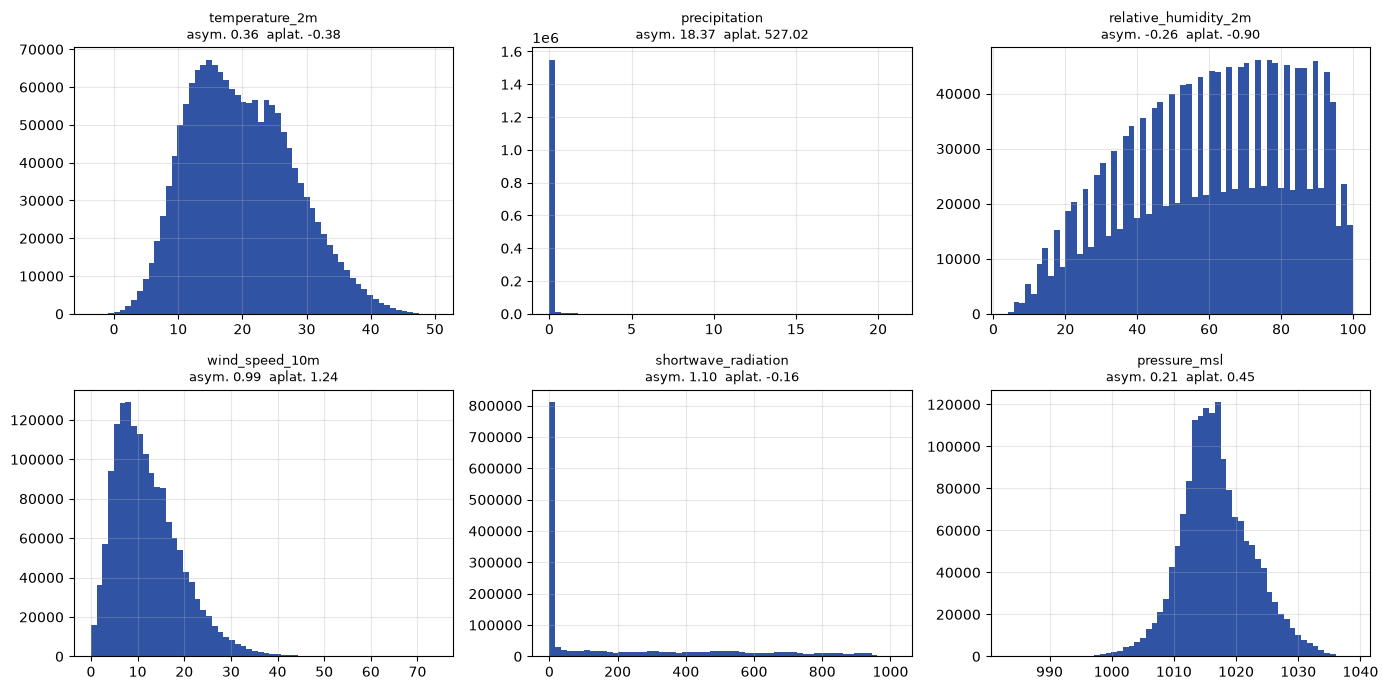

In [15]:
CLES = ["temperature_2m", "precipitation", "relative_humidity_2m",
        "wind_speed_10m", "shortwave_radiation", "pressure_msl"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, variable in zip(axes.ravel(), CLES):
    ax.hist(df[variable].values, bins=60, color=MARINE, alpha=0.85)
    ax.set_title(f"{variable}\nasym. {df[variable].skew():.2f}  "
                 f"aplat. {df[variable].kurtosis():.2f}", fontsize=9)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

La temperature est **bimodale** : les deux bosses correspondent aux saisons,
pas a deux populations distinctes. Le rayonnement presente un pic marque a zero
— toutes les heures de nuit. La pression est la seule variable proche d'une
gaussienne.

### Dispersion par famille d'unites

Un boxplot unique serait illisible : le rayonnement monte a 1 400 W/m² quand
l'humidite du sol reste sous 0,54 m³/m³. Les variables sont donc regroupees par
unite.

Les points au-dela des moustaches ne sont **pas traces** : sur 1,58 million de
lignes ils se comptent en centaines de milliers et masqueraient les boites. Ce
ne sont d'ailleurs pas des erreurs de saisie mais des evenements
meteorologiques reels — les valeurs aberrantes au sens strict sont deja
traitees par les controles de plage de `01_etl/checks.py`.

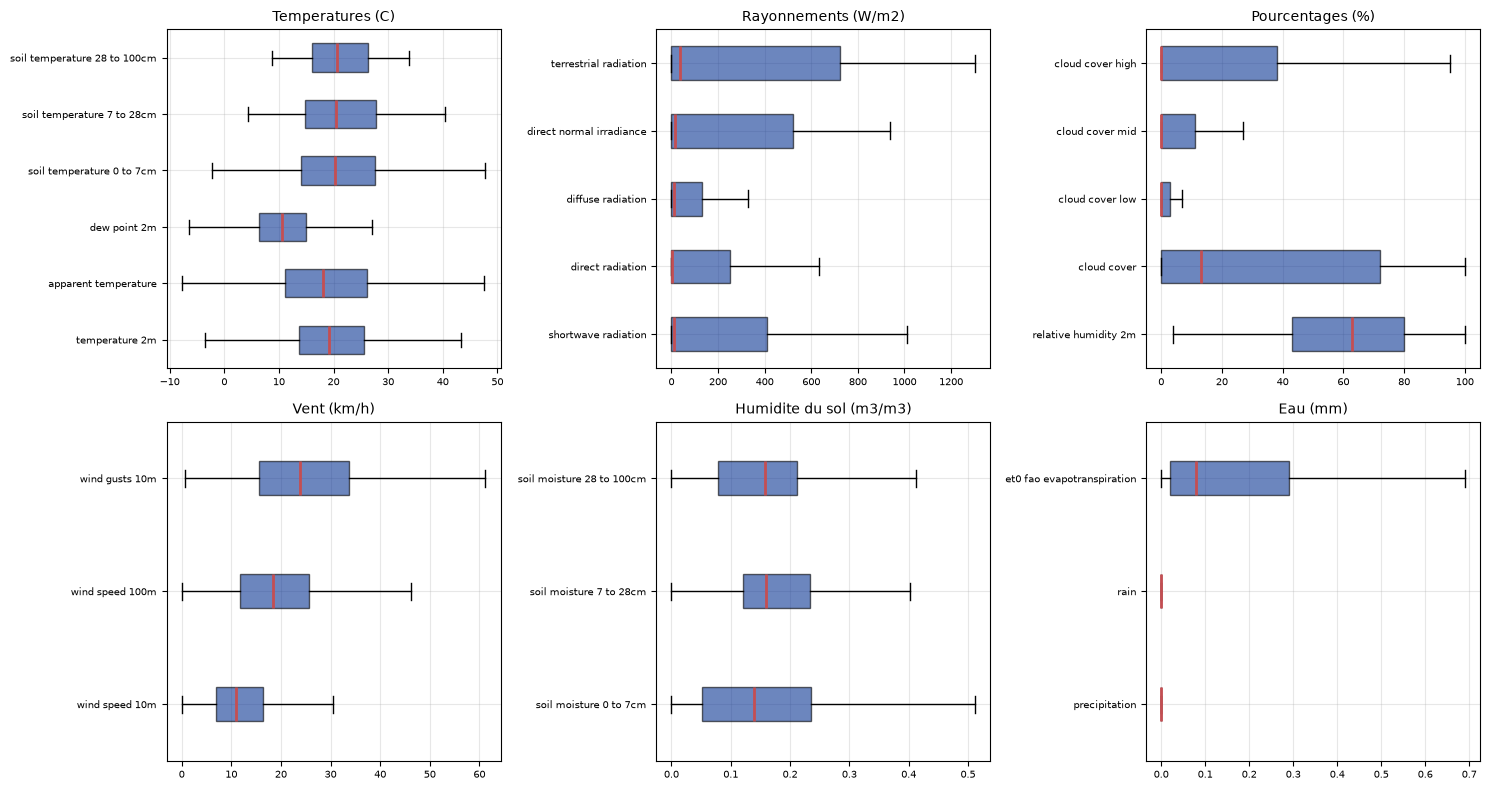

In [16]:
FAMILLES = {
    "Temperatures (C)": ["temperature_2m", "apparent_temperature",
                         "dew_point_2m", "soil_temperature_0_to_7cm",
                         "soil_temperature_7_to_28cm",
                         "soil_temperature_28_to_100cm"],
    "Rayonnements (W/m2)": ["shortwave_radiation", "direct_radiation",
                            "diffuse_radiation", "direct_normal_irradiance",
                            "terrestrial_radiation"],
    "Pourcentages (%)": ["relative_humidity_2m", "cloud_cover",
                         "cloud_cover_low", "cloud_cover_mid",
                         "cloud_cover_high"],
    "Vent (km/h)": ["wind_speed_10m", "wind_speed_100m", "wind_gusts_10m"],
    "Humidite du sol (m3/m3)": ["soil_moisture_0_to_7cm",
                                "soil_moisture_7_to_28cm",
                                "soil_moisture_28_to_100cm"],
    "Eau (mm)": ["precipitation", "rain", "et0_fao_evapotranspiration"],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (titre, colonnes) in zip(axes.ravel(), FAMILLES.items()):
    ax.boxplot([df[c].values for c in colonnes],
               orientation="horizontal", showfliers=False,
               tick_labels=[c.replace("_", " ") for c in colonnes],
               patch_artist=True,
               boxprops=dict(facecolor=MARINE, alpha=0.6),
               medianprops=dict(color=BRIQUE, lw=2))
    ax.set_title(titre, fontsize=10)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Deux lectures utiles. Les trois couches de sol montrent une **dispersion
decroissante avec la profondeur** : le sol profond filtre les variations
rapides et porte l'inertie thermique saisonniere — un signal potentiellement
precieux pour la prevision. Et les rafales sont systematiquement decalees vers
le haut par rapport au vent moyen, ce qui est physiquement attendu.

## 6. Coherence entrainement / production

**C'est la section qui decide des variables du modele.**

Le modele s'entrainera sur la reanalyse ERA5 mais predira a partir de l'API
forecast, alimentee par un modele de prevision operationnel. Ces deux sources
ne coincident pas. Une variable dont elles divergent propagerait son biais
dans toutes ses variables de decalage, et le modele se degraderait en
production sans que rien ne l'annonce en validation.

La metrique de decision est **MAE / ecart-type** : le desaccord rapporte a la
variabilite propre de la variable, seule grandeur comparable entre des unites
differentes.

Mesure produite par `01_etl/skew_analysis.py` sur les 24 gouvernorats.

In [17]:
skew = pd.read_csv(config.SKEW_CSV)
print(f"{skew['gouvernorat'].nunique()} gouvernorats, "
      f"{skew['variable'].nunique()} variables, "
      f"{skew['n'].iloc[0]:,} heures communes par gouvernorat")

synthese = (skew.groupby("variable", as_index=False)
            .agg(biais=("biais", "mean"), mae=("mae", "mean"),
                 mae_sur_sigma=("mae_sur_sigma", "mean"))
            .sort_values("mae_sur_sigma")
            .round(3))
synthese

24 gouvernorats, 31 variables, 1,872 heures communes par gouvernorat


,variable,biais,mae,mae_sur_sigma
16,soil_moisture_0_to_7cm,0.000,0.000,0.000
17,soil_moisture_28_to_100cm,0.000,0.000,0.000
18,soil_moisture_7_to_28cm,-0.000,0.000,0.000
24,terrestrial_radiation,0.002,0.129,0.000
19,soil_temperature_0_to_7cm,-0.023,0.077,0.012
21,soil_temperature_7_to_28cm,-0.023,0.077,0.017
20,soil_temperature_28_to_100cm,-0.023,0.077,0.021
14,shortwave_radiation,2.800,16.342,0.047
12,rain,-0.013,0.014,0.070
10,precipitation,-0.007,0.016,0.083


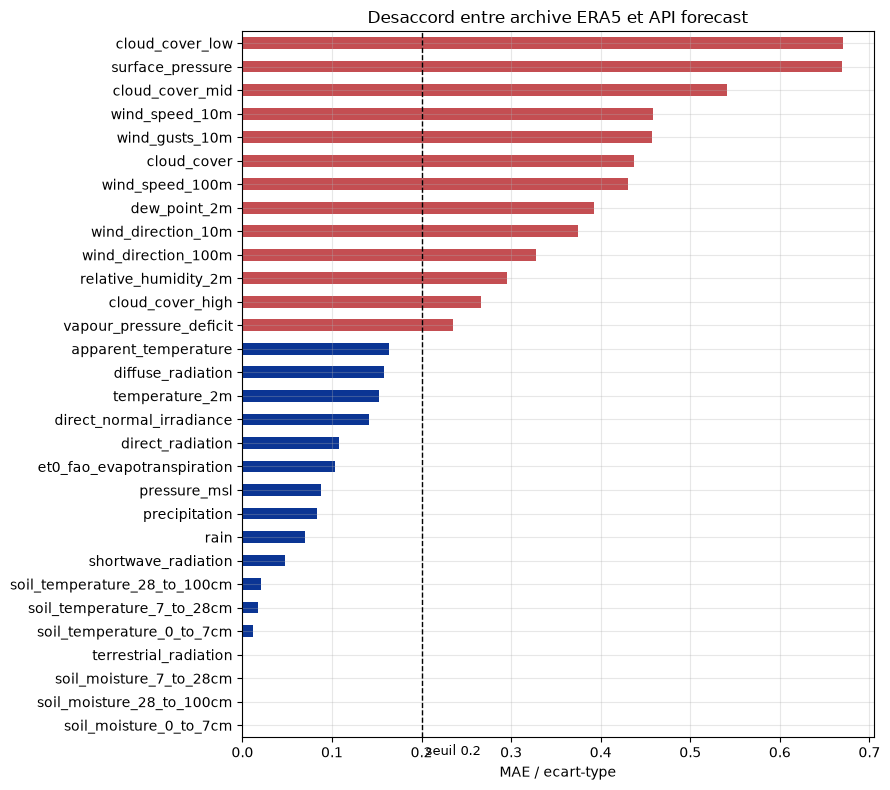

In [18]:
SEUIL = 0.2

trace = synthese.dropna(subset=["mae_sur_sigma"]).set_index("variable")
couleurs = [MARINE if v <= SEUIL else BRIQUE
            for v in trace["mae_sur_sigma"]]

ax = trace["mae_sur_sigma"].plot(kind="barh", color=couleurs, figsize=(9, 8))
ax.axvline(SEUIL, color="black", ls="--", lw=1)
ax.text(SEUIL, -0.8, f" seuil {SEUIL}", va="top", fontsize=9)
ax.set_xlabel("MAE / ecart-type")
ax.set_ylabel("")
ax.set_title("Desaccord entre archive ERA5 et API forecast")
plt.tight_layout()
plt.show()

### Ou placer le seuil

Le classement presente une rupture nette : le saut le plus large de la zone
separe `apparent_temperature` de `vapour_pressure_deficit`. Le seuil est place
a **0.2** dans cet intervalle — il decoule de la distribution
observee, il n'est pas un chiffre rond choisi d'avance.

In [19]:
SEUIL = 0.2

valides = synthese.dropna(subset=["mae_sur_sigma"])
retenues = sorted(valides.loc[valides["mae_sur_sigma"] <= SEUIL, "variable"])
ecartees = sorted(valides.loc[valides["mae_sur_sigma"] > SEUIL, "variable"])
indefinies = sorted(synthese.loc[synthese["mae_sur_sigma"].isna(), "variable"])

print(f"RETENUES ({len(retenues)}) :")
for v in retenues:
    print(f"  {v}")
print(f"\nECARTEES ({len(ecartees)}) :")
for v in ecartees:
    print(f"  {v}")
if indefinies:
    print(f"\nINDETERMINEES ({len(indefinies)}) :")
    for v in indefinies:
        print(f"  {v}  (ecart-type nul sur la fenetre : non evaluable)")

RETENUES (17) :


  apparent_temperature
  diffuse_radiation
  direct_normal_irradiance
  direct_radiation
  et0_fao_evapotranspiration
  precipitation
  pressure_msl
  rain
  shortwave_radiation
  soil_moisture_0_to_7cm
  soil_moisture_28_to_100cm
  soil_moisture_7_to_28cm
  soil_temperature_0_to_7cm
  soil_temperature_28_to_100cm
  soil_temperature_7_to_28cm
  temperature_2m
  terrestrial_radiation

ECARTEES (13) :
  cloud_cover
  cloud_cover_high
  cloud_cover_low
  cloud_cover_mid
  dew_point_2m
  relative_humidity_2m
  surface_pressure
  vapour_pressure_deficit
  wind_direction_100m
  wind_direction_10m
  wind_gusts_10m
  wind_speed_100m
  wind_speed_10m

INDETERMINEES (1) :
  snowfall  (ecart-type nul sur la fenetre : non evaluable)


### Trois enseignements

**Les variables de sol et le rayonnement terrestre sont identiques au
millieme.** Pour le rayonnement terrestre c'est attendu : il est purement
astronomique, calcule a partir de la geometrie Soleil-Terre, pas simule.

**`surface_pressure` est ecartee alors que `pressure_msl` est retenue.** La
pression de surface depend de l'altitude du relief tel que chaque modele le
represente, et les deux modeles ne partagent pas le meme relief. La pression
ramenee au niveau de la mer, elle, est normalisee — d'ou son excellent accord.
Sans cette mesure, `surface_pressure` serait entree dans le modele.

**Nebulosite, vents et humidite relative divergent nettement.** Ce sont
justement des variables a fort pouvoir explicatif ; les ecarter coute du
signal, mais en conserver aurait coute davantage en production.

In [20]:
# Le desaccord est-il homogene entre gouvernorats, ou depend-il du lieu ?
dispersion = (skew.groupby("variable")["mae_sur_sigma"]
              .agg(["min", "mean", "max"]).round(3)
              .sort_values("mean"))
dispersion

,min,mean,max
variable,,,
soil_moisture_0_to_7cm,0.000,0.000,0.000
terrestrial_radiation,0.000,0.000,0.000
soil_moisture_7_to_28cm,0.000,0.000,0.003
soil_moisture_28_to_100cm,0.000,0.000,0.000
soil_temperature_0_to_7cm,0.000,0.012,0.102
soil_temperature_7_to_28cm,0.000,0.017,0.152
soil_temperature_28_to_100cm,0.000,0.021,0.181
shortwave_radiation,0.028,0.047,0.068
rain,0.007,0.070,0.117


### Limites de cette mesure

**Couverture saisonniere partielle.** L'API forecast ne remonte qu'a 92 jours :
la comparaison ne couvrira jamais l'hiver. Les biais mesures en saison chaude
pourraient differer en saison froide. Limite a assumer telle quelle dans le
rapport.

**Variables sans variance.** `snowfall` ressort indeterminee : il n'a pas neige
sur la fenetre, donc son ecart-type est nul et le rapport indefini. La methode
ne peut pas juger une variable constante.

**Variables circulaires.** Les MAE sur `wind_direction_10m` et
`wind_direction_100m` ne sont pas interpretables : 359 degres et 1 degre sont
voisins mais donnent un ecart de 358. Ces deux variables sont ecartees par
ailleurs, mais leur chiffre ne doit pas etre presente comme une mesure valide.

## 7. Correlations entre variables retenues

Maintenant que les variables utilisables sont fixees, reste a savoir comment
elles se comportent **entre elles**.

$$
\rho_{x,y} = \frac{\operatorname{cov}(x, y)}{\sigma_x \, \sigma_y}
\qquad
\operatorname{cov}(x, y) = \frac{1}{n}\sum_{i=1}^{n}
(x_i - \bar{x})(y_i - \bar{y})
$$

La question n'est pas academique : cinq variables de rayonnement et trois
couches de temperature de sol figurent parmi les retenues. Si elles portent la
meme information, les empiler multiplie le nombre de features sans rien
apporter, et desequilibre les modeles lineaires.

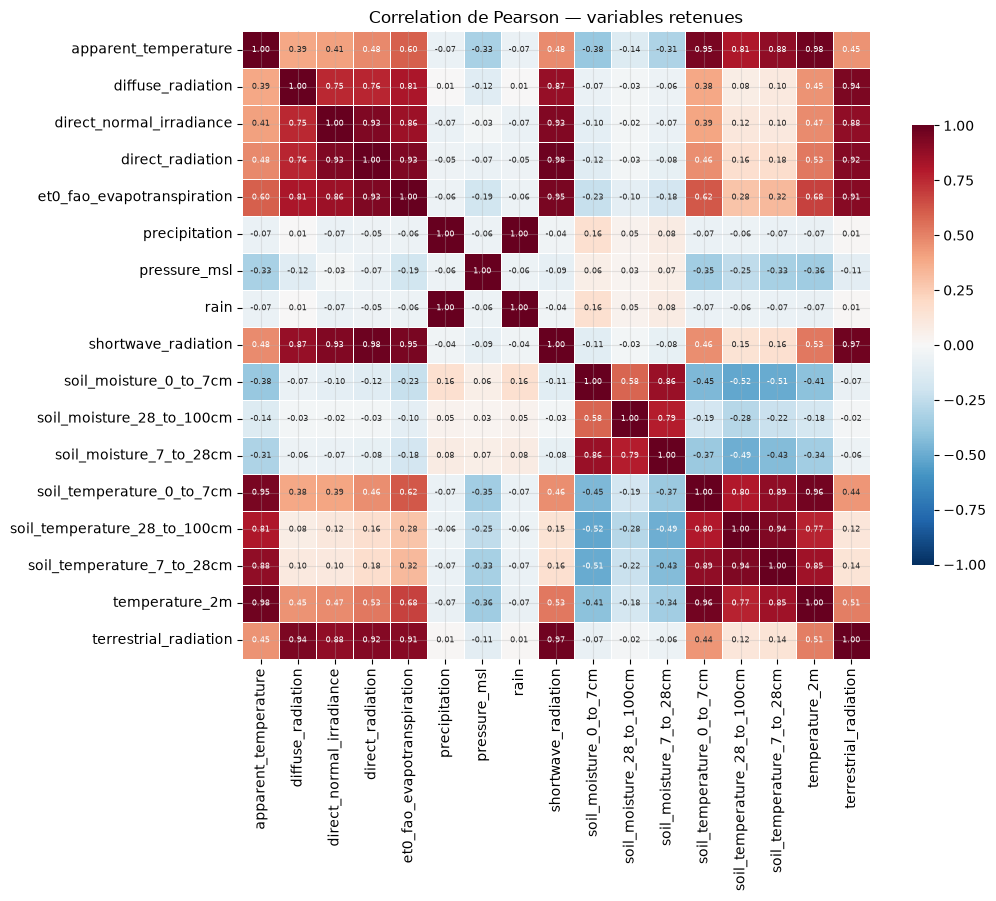

In [21]:
correlations = df[retenues].corr(method="pearson")

f, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlations, annot=True, fmt=".2f", annot_kws={"size": 6},
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation de Pearson — variables retenues")
plt.tight_layout()
plt.show()

In [22]:
# Paires fortement correlees : candidates a l'elimination
SEUIL_COLIN = 0.90

# Triangle superieur seul : sinon chaque paire apparait deux fois
triangle = np.triu(np.ones(correlations.shape, dtype=bool), k=1)

paires = (correlations.where(triangle)
          .stack()
          .rename("correlation")
          .reset_index()
          .rename(columns={"level_0": "variable_1", "level_1": "variable_2"}))

fortes = (paires[paires["correlation"].abs() >= SEUIL_COLIN]
          .sort_values("correlation", key=abs, ascending=False)
          .round(3)
          .reset_index(drop=True))

print(f"{len(fortes)} paires avec |correlation| >= {SEUIL_COLIN}\n")
fortes

14 paires avec |correlation| >= 0.9



,variable_1,variable_2,correlation
0,precipitation,rain,1.000
1,direct_radiation,shortwave_radiation,0.982
2,apparent_temperature,temperature_2m,0.975
3,shortwave_radiation,terrestrial_radiation,0.971
4,soil_temperature_0_to_7cm,temperature_2m,0.964
5,apparent_temperature,soil_temperature_0_to_7cm,0.951
6,et0_fao_evapotranspiration,shortwave_radiation,0.946
7,diffuse_radiation,terrestrial_radiation,0.943
8,soil_temperature_28_to_100cm,soil_temperature_7_to_28cm,0.935
9,direct_radiation,et0_fao_evapotranspiration,0.933


### Consequences pour la modelisation

Les groupes colineaires identifies ci-dessus ne seront pas tous conserves. Deux
consequences concretes pour la phase 06 :

**Le feature engineering est allege.** Construire huit decalages et trois
fenetres glissantes pour cinq rayonnements quasi identiques multiplierait les
colonnes sans ajouter d'information. Un representant par groupe suffit.

**Ridge et Lasso sont justifies, pas decoratifs.** La colinearite rend les
coefficients d'une regression ordinaire instables — de petites variations des
donnees produisent de grands changements de coefficients. C'est precisement le
probleme que la regularisation traite, et c'est ce qui rend leur comparaison
avec la regression simple interessante plutot que rituelle.

Le Lasso apportera en outre une reponse independante : les variables qu'il
annule seront a confronter a ces groupes.

## 8. Synthese et consequences

**Le jeu est exploitable en l'etat.** Continuite horaire parfaite, aucune
valeur manquante, aucun doublon. La seule correction necessaire portait sur
les humidites de sol negatives, appliquee par `01_etl/clean.py`.

**Le gradient nord-sud structure les donnees**, et l'altitude compte autant
que la latitude. Latitude, longitude et altitude porteront donc les
specificites locales du modele global.

**Deux saisonnalites coexistent**, diurne et annuelle. C'est la contrainte
centrale de la phase 05.

**Les variables du modele sont fixees par la mesure de coherence**, pas par
intuition. Le detail par gouvernorat est dans `data/skew_era5_forecast.csv`.

### Suite

- **Phase 02** — schema en etoile DuckDB a partir du Parquet propre.
- **Phase 04** — clustering climatique, en gardant en tete l'artefact du Grand
  Tunis.
- **Phase 05** — ACF/PACF pour justifier les decalages, puis ARIMA, SARIMA et
  Fourier + ARIMA.
- **Phase 06** — `build_features()` restreinte aux variables retenues ici.